# Observations - PARA
L1: s-c

L2: sh-ch

In this version, we consider both RC-first and CL-first runs. That is, all four combinations: RCRC, RCCL, CLRC, CLCL. 

In [1]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

In [2]:
# plot for each condition
L1_CONDITION_MAP = {
    "0203_RCRC_PARA_FZ_1e5": "Recon", 
    "0203_RCCL_PARA_FZ_1e5": "Recon",
    "0203_RCRC_PARA_NFZ_1e5": "Recon",
    "0203_RCCL_PARA_NFZ_1e5": "Recon", 
    "0203_CLRC_PARA_FZ_1e5": "Class", 
    "0203_CLCL_PARA_FZ_1e5": "Class",
    "0203_CLRC_PARA_NFZ_1e5": "Class",
    "0203_CLCL_PARA_NFZ_1e5": "Class", 
}

L2_CONDITION_MAP = {
    "0203_RCRC_PARA_FZ_1e5": "Recon", 
    "0203_RCCL_PARA_FZ_1e5": "Class",
    "0203_RCRC_PARA_NFZ_1e5": "Recon",
    "0203_RCCL_PARA_NFZ_1e5": "Class", 
    "0203_CLRC_PARA_FZ_1e5": "Recon", 
    "0203_CLCL_PARA_FZ_1e5": "Class",
    "0203_CLRC_PARA_NFZ_1e5": "Recon",
    "0203_CLCL_PARA_NFZ_1e5": "Class", 
}

FREEZING_CONDITION_MAP = {
    "0203_RCRC_PARA_FZ_1e5": "Freeze", 
    "0203_RCCL_PARA_FZ_1e5": "Freeze",
    "0203_RCRC_PARA_NFZ_1e5": "NoFreeze",
    "0203_RCCL_PARA_NFZ_1e5": "NoFreeze", 
    "0203_CLRC_PARA_FZ_1e5": "Freeze", 
    "0203_CLCL_PARA_FZ_1e5": "Freeze",
    "0203_CLRC_PARA_NFZ_1e5": "NoFreeze",
    "0203_CLCL_PARA_NFZ_1e5": "NoFreeze", 
}

BASE_PATH = "./observations/"
EPOCH_START = 10
EPOCH_END = 200
EVAL_METHOD = "silhouette"
RUNS = [1, 2, 3, 4, 5, 6]

TRAIN_MAP = {
    "sh_ch": "L2", "s_c": "L1"
}

integrated_df = pd.DataFrame()
for condition in L1_CONDITION_MAP.keys(): 
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            file_path = condition_path + f"{EVAL_METHOD}_E{epoch}_R{run}.csv"
            df = pd.read_csv(file_path)
            
            scores = df["sil_score"].tolist()
            train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

            result_df = pd.DataFrame({
                "L1_condition": [L1_CONDITION_MAP[condition]] * len(scores),
                "L2_condition": [L2_CONDITION_MAP[condition]] * len(scores),
                "freezing_condition": [FREEZING_CONDITION_MAP[condition]] * len(scores),
                "contrast_pair": df["sil_type"].tolist(),
                "train_lang": train_langs,
                "sil_score": scores, 
                "run": [run] * len(scores),
                "epoch": [epoch] * len(scores)})
            integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

In [4]:
# integrate L1 and L2 conditions into one column for better visualization
integrated_df["combined_condition"] = integrated_df["L1_condition"] + "_" + integrated_df["L2_condition"]

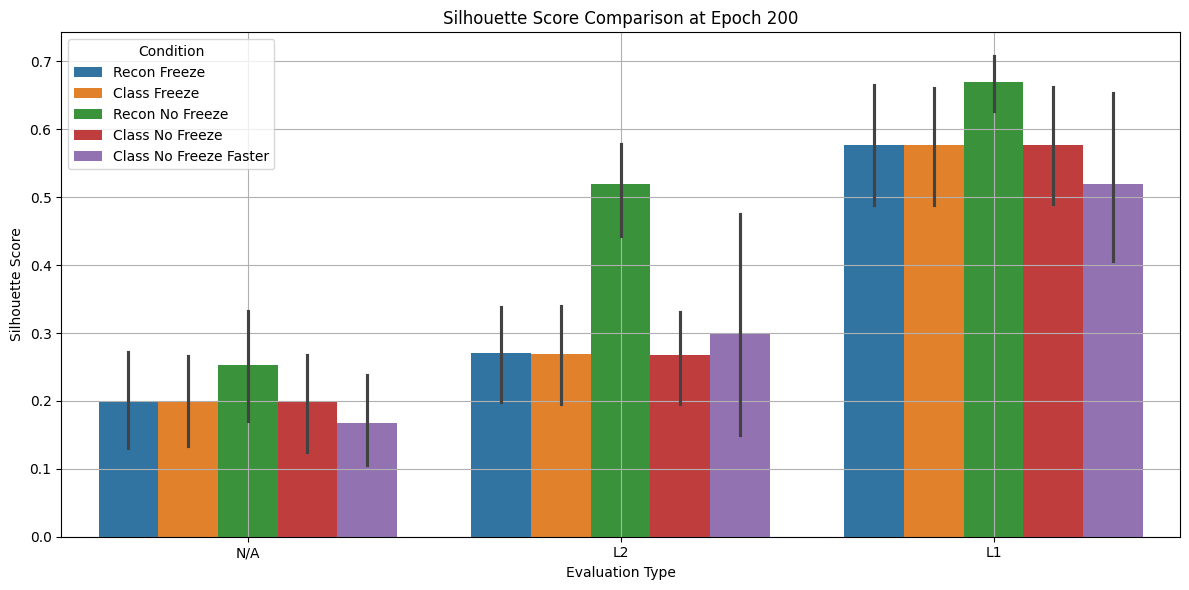

In [34]:
# draw the last epoch comparison across conditions, organize first by eval type then by condition
final_epoch = 200
final_df = pd.DataFrame()
for condition, label in CONDITIONS_MAP.items(): 
    condition_df = collected_results[label]
    epoch_df = condition_df[condition_df["epoch"] == final_epoch]
    # epoch_df = epoch_df[~epoch_df["eval_type"].isin([TYPE_NAME.SAME, TYPE_NAME.SAME_L1, TYPE_NAME.SAME_L2])]
    epoch_df["condition"] = [label] * len(epoch_df)
    final_df = pd.concat([final_df, epoch_df], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=final_df, x="train_lang", y="sil_score", hue="condition", errorbar=("ci", 95))
plt.title(f"Silhouette Score Comparison at Epoch {final_epoch}")
plt.xlabel("Evaluation Type")
plt.ylabel("Silhouette Score")
plt.legend(title="Condition")
plt.grid(True)
plt.tight_layout()
plt.show()

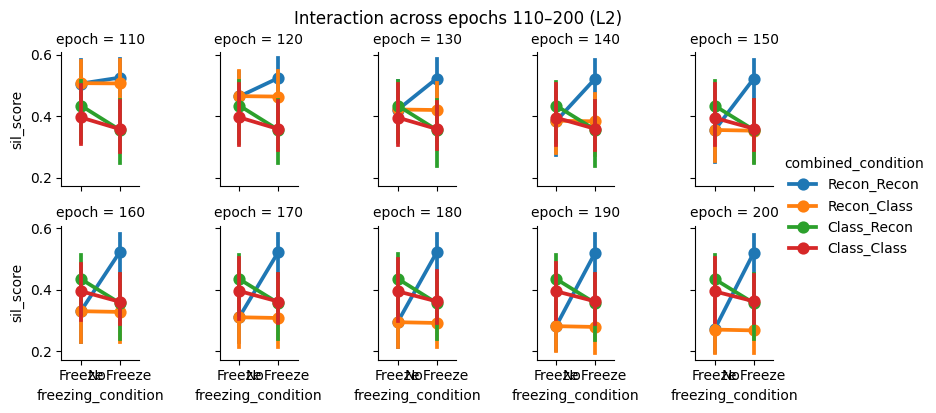

In [5]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = integrated_df.copy()
df = df[df["train_lang"] == "L2"]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freezing_condition",
    y="sil_score",
    hue="combined_condition",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (L2)", y=1.02)
plt.show()

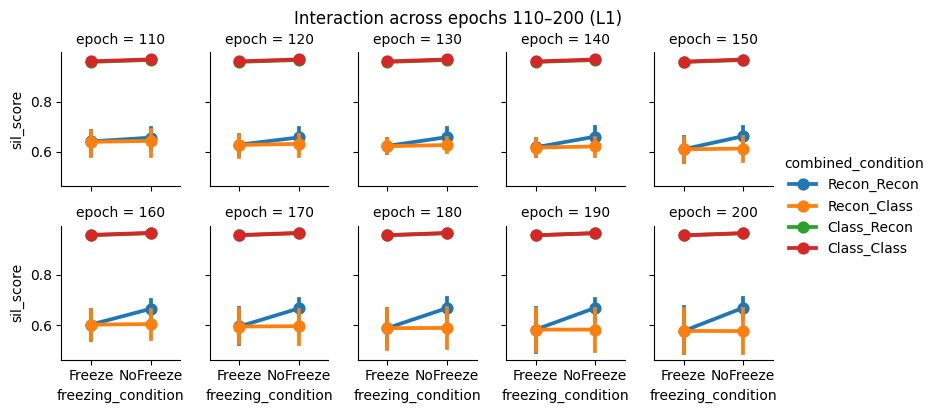

In [6]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = integrated_df.copy()
df = df[df["train_lang"] == "L1"]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freezing_condition",
    y="sil_score",
    hue="combined_condition",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (L1)", y=1.02)
plt.show()

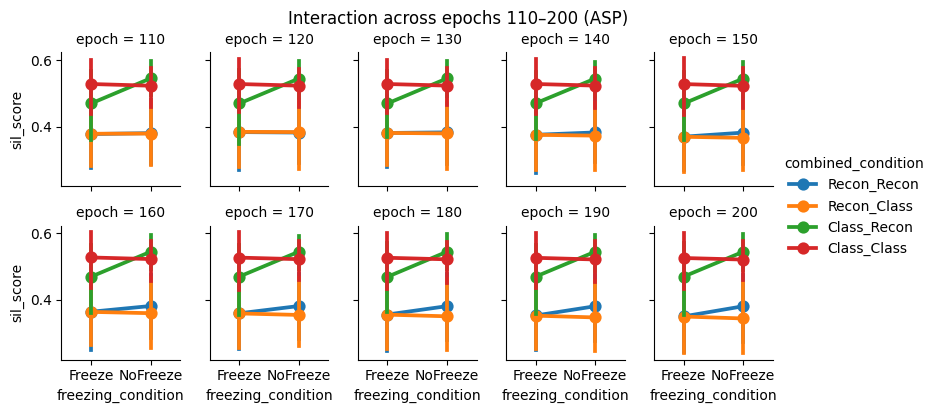

In [7]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = integrated_df.copy()
df = df[df["contrast_pair"].isin(["sh_s", "ch_c"])]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freezing_condition",
    y="sil_score",
    hue="combined_condition",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (ASP)", y=1.02)
plt.show()

In [8]:
integrated_df

,L1_condition,L2_condition,freezing_condition,contrast_pair,train_lang,sil_score,run,epoch,combined_condition
0,Recon,Recon,Freeze,sh_sh,N/A,-0.000128,1,10,Recon_Recon
1,Recon,Recon,Freeze,sh_ch,L2,0.364393,1,10,Recon_Recon
2,Recon,Recon,Freeze,sh_s,N/A,0.515042,1,10,Recon_Recon
3,Recon,Recon,Freeze,sh_c,N/A,0.464610,1,10,Recon_Recon
4,Recon,Recon,Freeze,ch_ch,N/A,0.000017,1,10,Recon_Recon
...,...,...,...,...,...,...,...,...,...
9595,Class,Class,NoFreeze,ch_s,N/A,0.921941,6,200,Class_Class
9596,Class,Class,NoFreeze,ch_c,N/A,0.260528,6,200,Class_Class
9597,Class,Class,NoFreeze,s_s,N/A,-0.000168,6,200,Class_Class
9598,Class,Class,NoFreeze,s_c,L1,0.964842,6,200,Class_Class


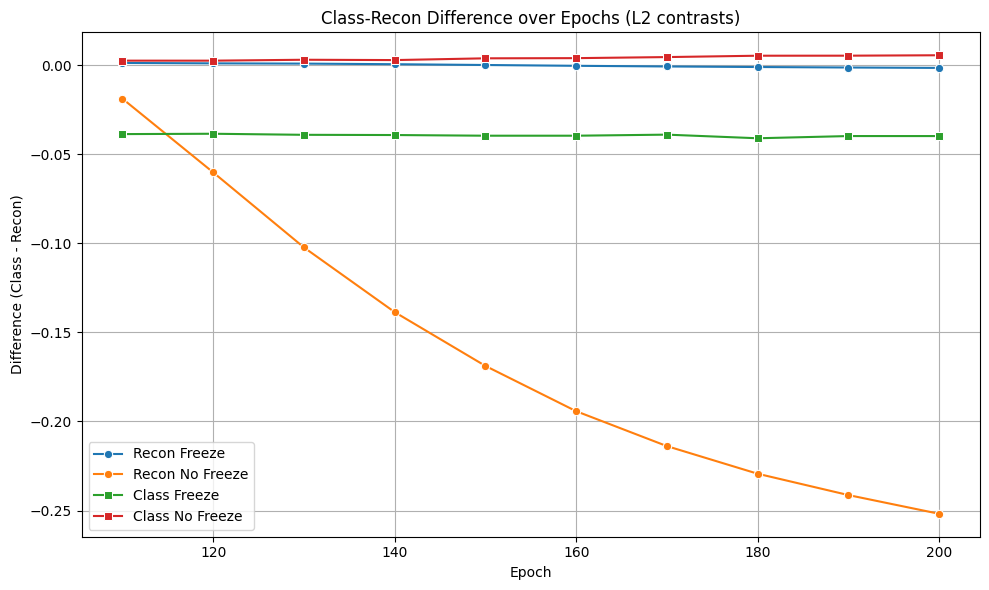

In [14]:
L1_rc_diffs = []
L1_cl_diffs = []
# draw the epoch-development of the interaction effect
df = integrated_df.copy()
for epoch in range(110, EPOCH_END + 1, 10):
    df_epoch = df[df["epoch"] == epoch]
    df_epoch = df_epoch[df_epoch["train_lang"].isin(["L2"])]
    means = df_epoch.groupby(["L1_condition", "L2_condition", "freezing_condition"])["sil_score"].mean()
    L1_rc_diffs.append({"epoch": epoch, 
                        "diff_freeze": means["Recon", "Class", "Freeze"] - means["Recon", "Recon", "Freeze"], 
                        "diff_nofreeze": means["Recon", "Class", "NoFreeze"] - means["Recon", "Recon", "NoFreeze"]})

    L1_cl_diffs.append({"epoch": epoch, 
                        "diff_freeze": means["Class", "Class", "Freeze"] - means["Class", "Recon", "Freeze"], 
                        "diff_nofreeze": means["Class", "Class", "NoFreeze"] - means["Class", "Recon", "NoFreeze"]})


L1_rc_diffs_df = pd.DataFrame(L1_rc_diffs)
L1_cl_diffs_df = pd.DataFrame(L1_cl_diffs)

plt.figure(figsize=(10, 6))
sns.lineplot(data=L1_rc_diffs_df, x="epoch", y="diff_freeze", marker="o", label="Recon Freeze")
sns.lineplot(data=L1_rc_diffs_df, x="epoch", y="diff_nofreeze", marker="o", label="Recon No Freeze")

sns.lineplot(data=L1_cl_diffs_df, x="epoch", y="diff_freeze", marker="s", label="Class Freeze")
sns.lineplot(data=L1_cl_diffs_df, x="epoch", y="diff_nofreeze", marker="s", label="Class No Freeze")

plt.title("Class-Recon Difference over Epochs (L2 contrasts)")
plt.xlabel("Epoch")
plt.ylabel("Difference (Class - Recon)")
plt.grid(True)
plt.tight_layout()
plt.show()

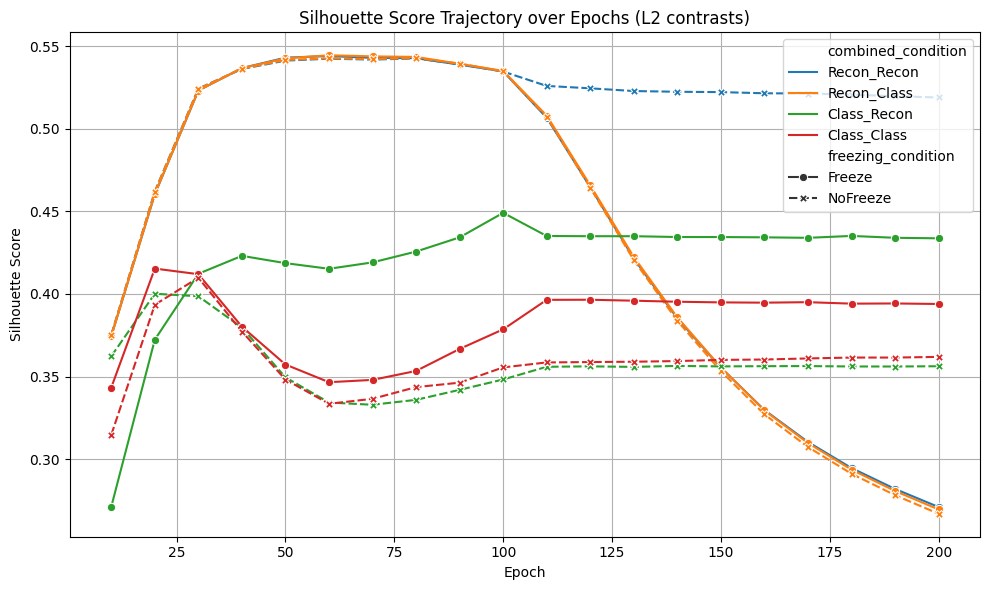

In [27]:
all_plot_df = integrated_df.copy()
# all_plot_df = all_plot_df[all_plot_df["epoch"].between(110, 200)]
all_plot_df = all_plot_df[all_plot_df["train_lang"] == "L2"]

plt.figure(figsize=(10, 6))
# plot trajectory of all conditions (L1_condition, L2_condition, freezing_condition)
sns.lineplot(data=all_plot_df, x="epoch", y="sil_score", hue="combined_condition", style="freezing_condition", markers=True, errorbar=None)

plt.title("Silhouette Score Trajectory over Epochs (L2 contrasts)")
plt.xlabel("Epoch")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

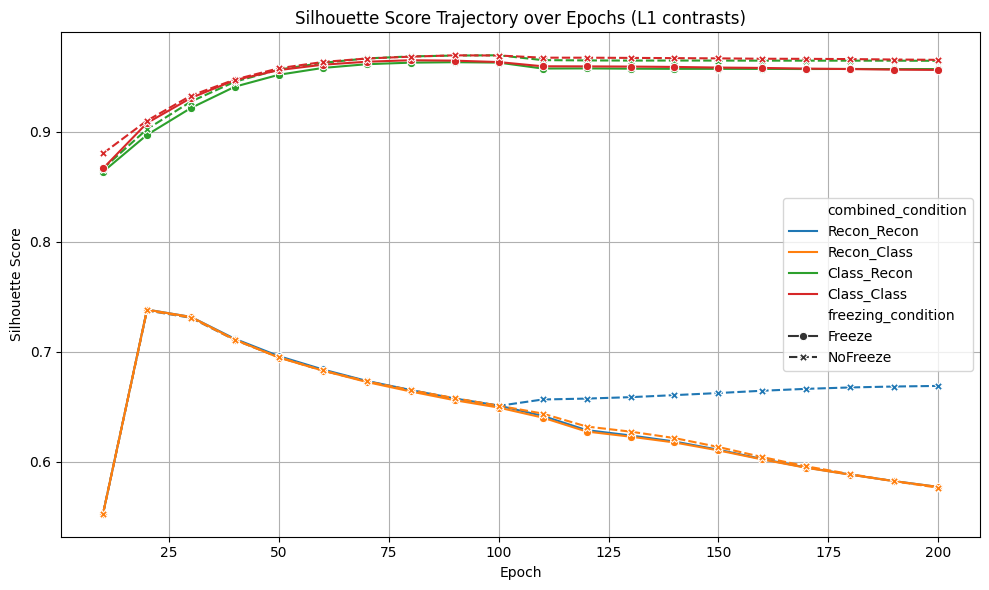

In [26]:
all_plot_df = integrated_df.copy()
# all_plot_df = all_plot_df[all_plot_df["epoch"].between(110, 200)]
all_plot_df = all_plot_df[all_plot_df["train_lang"] == "L1"]

plt.figure(figsize=(10, 6))
# plot trajectory of all conditions (L1_condition, L2_condition, freezing_condition)
sns.lineplot(data=all_plot_df, x="epoch", y="sil_score", hue="combined_condition", style="freezing_condition", markers=True, errorbar=None)

plt.title("Silhouette Score Trajectory over Epochs (L1 contrasts)")
plt.xlabel("Epoch")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
import hashlib
def make_seed(base_seed: int, condition: str="", run_id: int=1) -> int:
    """
    Derive a stable 32-bit seed from (base_seed, condition string, run_id).
    This is deterministic across machines and Slurm jobs.
    """
    s = f"{base_seed}|{condition}|{run_id}".encode("utf-8")
    h = hashlib.sha256(s).hexdigest()
    return int(h[:8], 16)  # 32-bit

# IMPORTANT
It seems that either there is some systematic running configuration differences between L1RC and L1CL. Maybe it is something due to randomizations in same run across conditions. 

## Basic observations on learning trajectory
- the geometry of the training tokens seems to affect the relationship between Class/Recon and Freeze/NoFreeze

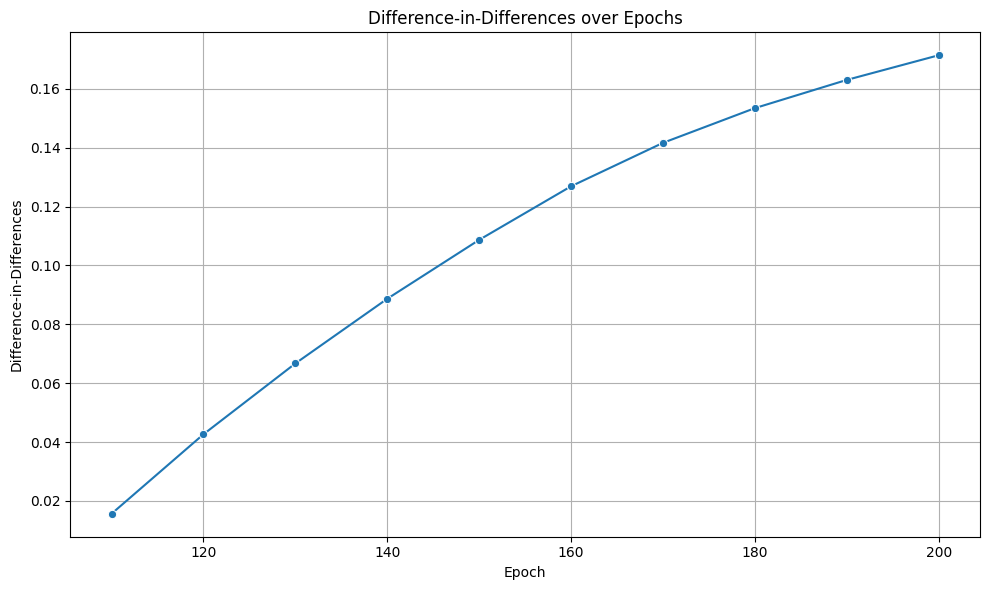

In [41]:
dffindff = []
# draw the epoch-development of the interaction effect
for epoch in range(110, EPOCH_END + 1, 10):
    df_epoch = collected_results_combined
    # df_epoch = df_epoch[df_epoch["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
    # df_epoch = df_epoch[df_epoch["contrast_pair"] == "tsh_ch"]
    # df_epoch = df_epoch[df_epoch["eval_lang"] == L_NAME.L2]
    df_epoch = df_epoch[df_epoch["train_lang"].isin(["L1", "L2"])]
    df_epoch = df_epoch[df_epoch["speed"] == "Normal"]
    df_epoch = df_epoch[df_epoch["epoch"] == epoch]
    # predicted marginal means
    means = df_epoch.groupby(["recon_class","freeze"])["sil_score"].mean()
    # print(means)
    # difference of differences
    diff = (means["Class","Freeze"] - means["Recon","Freeze"]) - \
        (means["Class","NoFreeze"] - means["Recon","NoFreeze"])

    # print("Difference-in-differences:", diff)
    dffindff.append({"epoch": epoch, "diff_in_diff": diff})

dffindff_df = pd.DataFrame(dffindff)
plt.figure(figsize=(10, 6))
sns.lineplot(data=dffindff_df, x="epoch", y="diff_in_diff", marker="o")
plt.title("Difference-in-Differences over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Difference-in-Differences")
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
df = collected_results_combined
# df = df[df["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
df = df[df["train_lang"].isin(["L1", "L2"])]
df = df[df["epoch"] == 200]
for c in ["eval_lang", "recon_class", "freeze", "run", "speed"]:
    df[c] = df[c].astype("category").cat.remove_unused_categories()

df["recon_class"] = df["recon_class"].cat.reorder_categories(
    ["Recon", "Class"], ordered=True
)

df["freeze"] = df["freeze"].cat.reorder_categories(
    ["NoFreeze", "Freeze"], ordered=True
)

cols = ["sil_score","eval_lang","recon_class","freeze","run", "speed"]
df = df.dropna(subset=cols)

def fit(formula):
    return smf.mixedlm(formula, df, groups=df["run"]).fit(reml=False)

full = fit("sil_score ~ recon_class * freeze + eval_lang + speed")
full.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Mixed Linear Model Regression Results
================================================================================
Model:                     MixedLM         Dependent Variable:         sil_score
No. Observations:          60              Method:                     ML       
No. Groups:                6               Scale:                      0.0123   
Min. group size:           10              Log-Likelihood:             43.4988  
Max. group size:           10              Converged:                  Yes      
Mean group size:           10.0                                                 
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                              0.711    0.061 11.680 0.000  0.591  0.830
recon_class[T.Class]                  -0.172    0.045 -3.808 0.000 -0.261 -0.084
freeze[T.Freeze]                      -0.170    0.045 -3.755 0.000 -0.258 -0.081
eval_lang[T.L2]                       -0.259    0.029 -9.062 0.000 -0.315 -0.203
speed[T.Normal]                        0.013    0.045  0.285 0.776 -0.076  0.101
recon_class[T.Class]:freeze[T.Freeze]  0.171    0.064  2.681 0.007  0.046  0.297
Group Var                              0.003    0.021                           
================================================================================

"""